# Transfer Visualizations

t-SNE visualizations of transfer experiments.

In [1]:
import pickle
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

## Load Data

In [2]:
agent_map_f = [
    "F only",
    "A only",
    "A → F",
    "C only",
    "C → F"
]

agent_map_i = [
    "I only",
    "A only",
    "A → I",
    "F only",
    "F → I"
]

with open("../trajs/gen9vgc2024regf_enc.pkl",'rb') as f:
    df_f: pd.DataFrame = pickle.load(f)
with open("../trajs/gen9vgc2025regi_enc.pkl",'rb') as f:
    df_i: pd.DataFrame = pickle.load(f)

# normalize depth
df_f["progress"] = df_f.groupby("traj")["depth"].transform(lambda x: x / x.max())
df_i["progress"] = df_i.groupby("traj")["depth"].transform(lambda x: x / x.max())

## Numerical Analysis

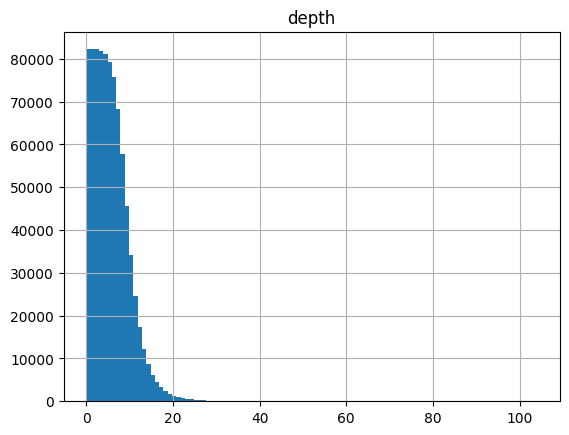

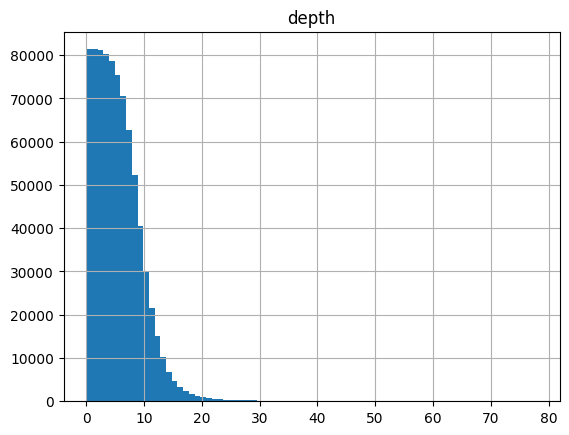

In [31]:
df_f.hist("depth", bins=len(df_f["depth"].unique()))
df_i.hist("depth", bins=len(df_i["depth"].unique()));

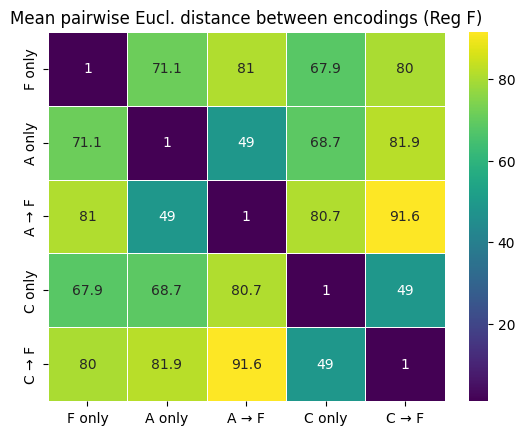

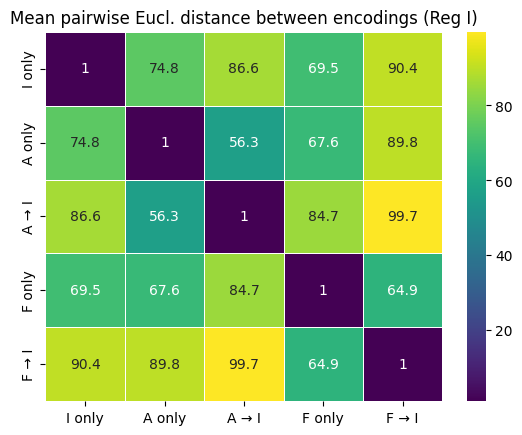

In [10]:
# mean pairwise distance between encodings
def mean_dist_enc(df, labels, reg):
    distance_matrix = np.identity(5)
    for i in range(len(labels)):
        for j in range(i):
            distance_matrix[i][j] = np.mean(np.linalg.norm(
                np.vstack(df[df["agent"] == i]["encoding"]) - np.vstack(df[df["agent"] == j]["encoding"]),
                axis=1
            ))
    distance_matrix = distance_matrix + distance_matrix.T - np.identity(5)

    sns.heatmap(
        distance_matrix,
        annot=True,
        fmt=".3g",
        cmap="viridis",
        linewidth=0.5,
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f"Mean pairwise Eucl. distance between encodings (Reg {reg})")
    plt.show()

mean_dist_enc(df_f, agent_map_f, "F")
mean_dist_enc(df_i, agent_map_i, "I")

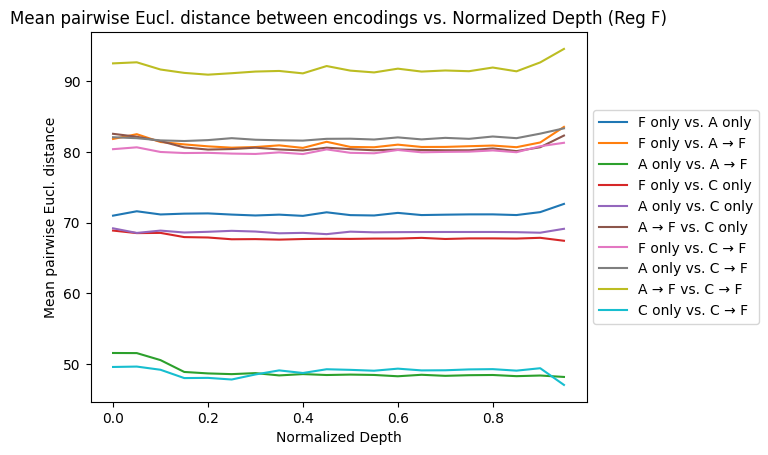

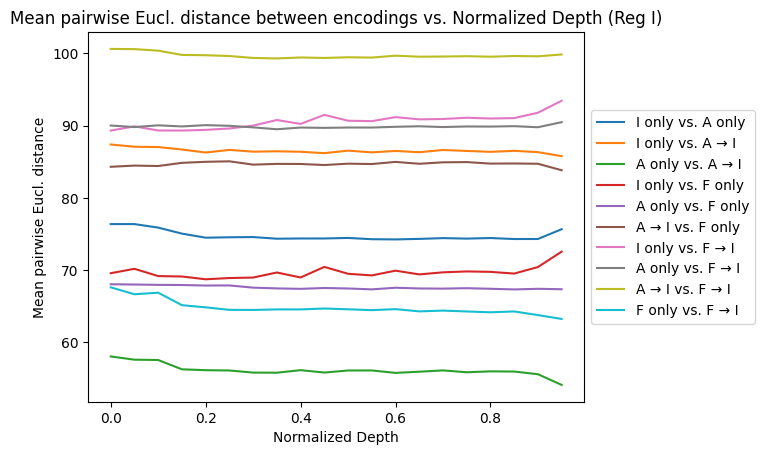

In [44]:
def mean_dist_enc_depth(df: pd.DataFrame, labels, reg):    
    depths = np.linspace(0, 1, num=20, endpoint=False)
    for i in range(len(labels)):
        for j in range(i):
            plt.plot(
                depths,
                [np.mean(np.linalg.norm(
                    np.vstack(df[(df["agent"] == i) & (d <= df["progress"]) & (df["progress"] < d+0.05)]["encoding"]) - \
                    np.vstack(df[(df["agent"] == j) & (d <= df["progress"]) & (df["progress"] < d+0.05)]["encoding"]),
                    axis=1
                )) for d in depths],
                label=f"{labels[j]} vs. {labels[i]}"
            )
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel("Normalized Depth")
    plt.ylabel("Mean pairwise Eucl. distance")
    plt.title(f"Mean pairwise Eucl. distance between encodings vs. Normalized Depth (Reg {reg})")
    plt.show()

mean_dist_enc_depth(df_f, agent_map_f, "F")
mean_dist_enc_depth(df_i, agent_map_i, "I")

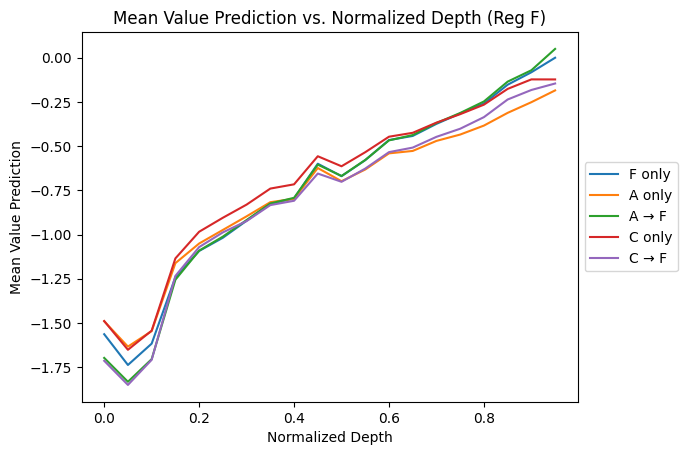

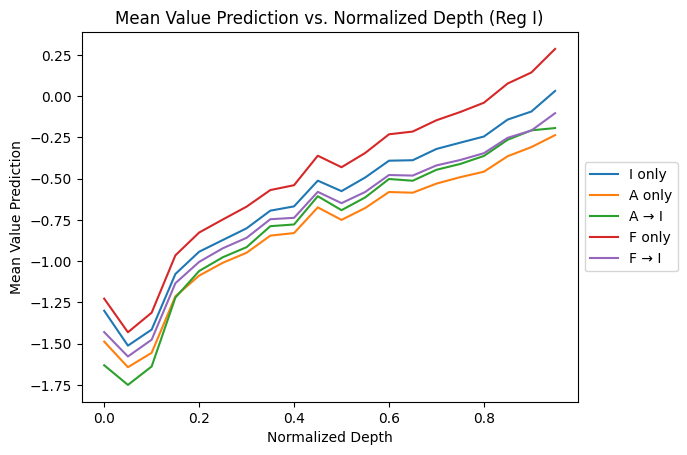

In [41]:
def mean_val_depth(df: pd.DataFrame, labels, reg):
    depths = np.linspace(0, 1, num=20, endpoint=False)
    for i in range(len(labels)):
        plt.plot(depths, [np.mean(
            np.vstack(df[(df["agent"] == i) & (d <= df["progress"]) & (df["progress"] < d+0.05)]["val"])
        ) for d in depths], label=labels[i])
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel("Normalized Depth")
    plt.ylabel("Mean Value Prediction")
    plt.title(f"Mean Value Prediction vs. Normalized Depth (Reg {reg})")
    plt.show()

mean_val_depth(df_f, agent_map_f, "F")
mean_val_depth(df_i, agent_map_i, "I")

In [13]:
for i in range(5):
    eigvals = np.linalg.eigvalsh(np.cov(np.vstack(df_f[df_f["agent"] == i]["encoding"]).T)) # type: ignore
    pr = eigvals.sum()**2 / np.square(eigvals).sum()
    print(f"Participation Ratio for {agent_map_f[i]}: {pr}")

print()
for i in range(5):
    eigvals = np.linalg.eigvalsh(np.cov(np.vstack(df_i[df_i["agent"] == i]["encoding"]).T)) # type: ignore
    pr = eigvals.sum()**2 / np.square(eigvals).sum()
    print(f"Participation Ratio for {agent_map_i[i]}: {pr}")
# significantly lower PR for the transferred agent -> representation collapse

Participation Ratio for F only: 8.550315505266965
Participation Ratio for A only: 10.072688891341848
Participation Ratio for A → F: 7.64182536147457
Participation Ratio for C only: 8.264021291737947
Participation Ratio for C → F: 6.811199952694637

Participation Ratio for I only: 7.412908995699742
Participation Ratio for A only: 11.062839169849157
Participation Ratio for A → I: 8.73758403505614
Participation Ratio for F only: 9.840797642766
Participation Ratio for F → I: 7.310090000264614


## t-SNE

In [9]:
RANDOM_STATE = 42
N_SAMPLES = 10_000 # number of states (in reality -> x5)

def tnse_encode(df: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    # random sample
    samples = df.merge(df.groupby(['traj','depth']).count().reset_index().sample(n=N_SAMPLES, random_state=RANDOM_STATE)[['traj','depth']])
    X = np.stack(samples["encoding"].values) #type: ignore

    # PCA preprocessing
    pca = PCA(n_components=50, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=RANDOM_STATE,
        verbose=1
    )
    return samples, tsne.fit_transform(X_pca)

try:
    with open(f"../trajs/regf_tsne{N_SAMPLES}_{RANDOM_STATE}.pkl",'rb') as f:
        df_sample_f, tsne_f = pickle.load(f)
    with open(f"../trajs/regi_tsne{N_SAMPLES}_{RANDOM_STATE}.pkl",'rb') as f:
        df_sample_i, tsne_i = pickle.load(f)
except FileNotFoundError:
    df_sample_f, tsne_f = tnse_encode(df_f)
    df_sample_i, tsne_i = tnse_encode(df_i)
    with open(f"../trajs/regf_tsne{N_SAMPLES}_{RANDOM_STATE}.pkl", "wb") as f:
        pickle.dump((df_sample_f, tsne_f), f)
    with open(f"../trajs/regi_tsne{N_SAMPLES}_{RANDOM_STATE}.pkl", "wb") as f:
        pickle.dump((df_sample_i, tsne_i), f)

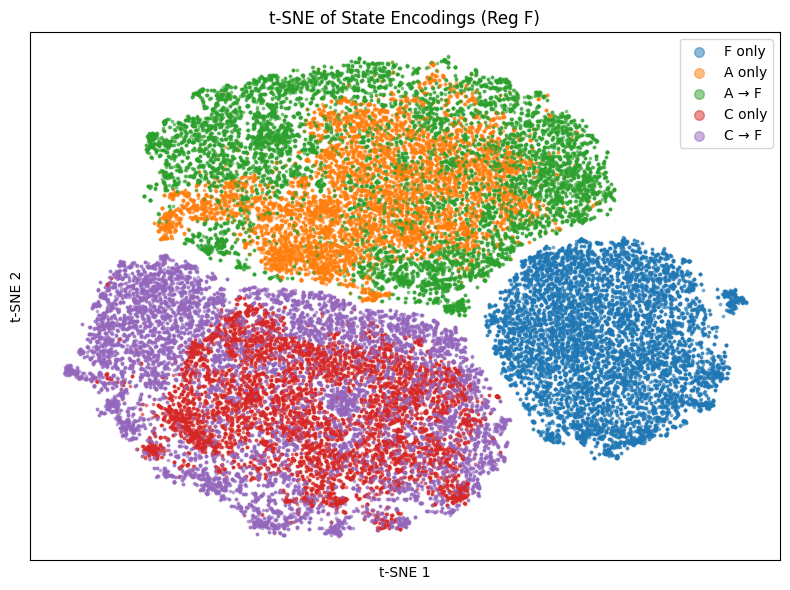

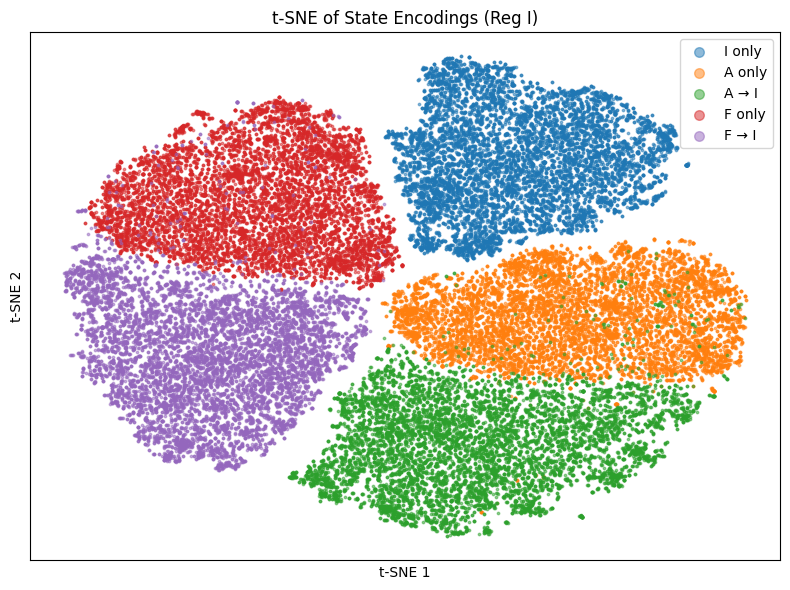

In [10]:
def plot_tnse(samples: pd.DataFrame, X_tsne: np.ndarray, agent_map: list[str], reg: str):
    plt.figure(figsize=(8, 6))

    for agent in range(len(agent_map)):
        mask = samples["agent"].values == agent
        plt.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            s=3,
            alpha=0.5,
            label=agent_map[agent]
        )

    plt.xlabel("t-SNE 1")
    plt.xticks([])
    plt.ylabel("t-SNE 2")
    plt.yticks([])
    plt.title(f"t-SNE of State Encodings (Reg {reg})")
    plt.legend(markerscale=4)
    plt.tight_layout()
    plt.show()

plot_tnse(df_sample_f, tsne_f, agent_map_f, "F")
plot_tnse(df_sample_i, tsne_i, agent_map_i, "I")

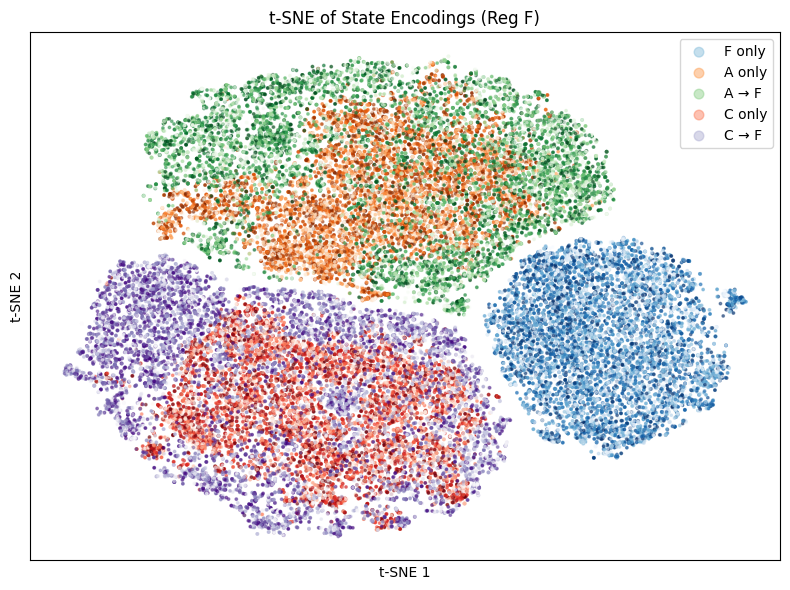

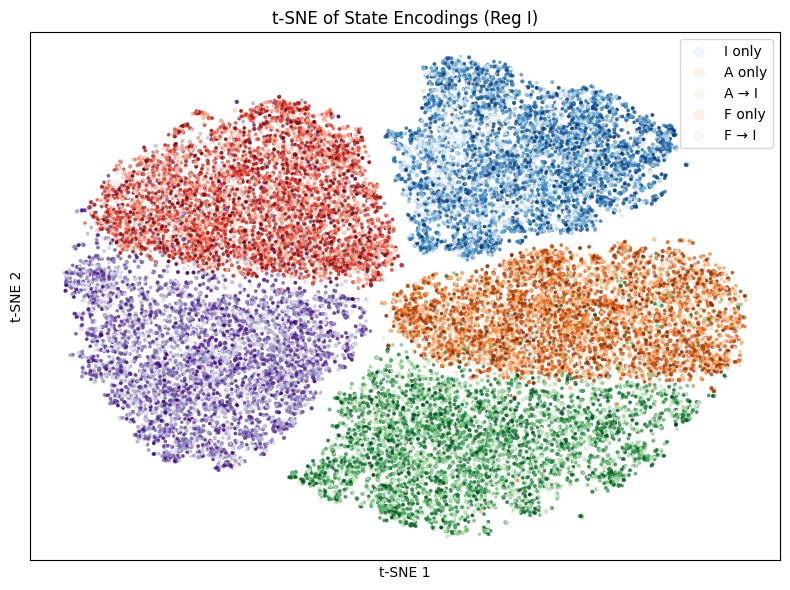

In [11]:
cmaps = [
    "Blues",
    "Oranges",
    "Greens",
    "Reds",
    "Purples"
]

def plot_tnse_grad(samples: pd.DataFrame, X_tsne: np.ndarray, agent_map: list[str], reg: str):
    plt.figure(figsize=(8, 6))

    # "progress" for normalized depth, "val" for value function
    progress = samples["progress"].values

    for agent in range(len(agent_map)):
        mask = samples["agent"].values == agent
        plt.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            c=progress[mask],
            cmap=cmaps[agent],
            s=3,
            alpha=0.5,
            label=agent_map[agent]
        )

    plt.xlabel("t-SNE 1")
    plt.xticks([])
    plt.ylabel("t-SNE 2")
    plt.yticks([])
    plt.title(f"t-SNE of State Encodings (Reg {reg})")
    plt.legend(markerscale=4)
    plt.tight_layout()
    plt.show()

plot_tnse_grad(df_sample_f, tsne_f, agent_map_f, "F")
plot_tnse_grad(df_sample_i, tsne_i, agent_map_i, "I")